Этап 2. Исследовательский анализ (EDA) и работа с данными
Поскольку у mdetection свои requerements я поставлю именно в ноут библиотеки чтобы не было конфликтов 

In [3]:
# 1. Импорт библиотек
import os
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image

plt.style.use("ggplot")
print("Setup complete. Imports successful.")

Setup complete. Imports successful.


In [5]:
# 2. Проверка структуры датасета
BASE_PATH = Path("datasets/minecraft")

train_dir = BASE_PATH / "train/images"
val_dir = BASE_PATH / "valid/images"
test_dir = BASE_PATH / "test/images"
ann_dir = BASE_PATH / "annotations"

print("Train exists:", train_dir.exists())
print("Val exists:", val_dir.exists())
print("Test exists:", test_dir.exists())
print("Annotations exists:", ann_dir.exists())

print("\nTrain images:", len(list(train_dir.glob("*.jpg"))))
print("Val images:", len(list(val_dir.glob("*.jpg"))))
print("Test images:", len(list(test_dir.glob("*.jpg"))))

Train exists: True
Val exists: True
Test exists: True
Annotations exists: True

Train images: 2307
Val images: 422
Test images: 155


In [6]:
# 3 за 4 файлов аннотаций присутствуют в папке annotations. Проверим их содержимое.
train_ann_path = ann_dir / "annotations_train.json"
test_ann_path = ann_dir / "annotations_test.json"
val_ann_path = ann_dir / "annotations_valid.json"

with open(train_ann_path) as f:
    coco_train = json.load(f)

print("Keys in COCO JSON train:")
print(coco_train.keys())

with open(test_ann_path) as f:
    coco_test = json.load(f)

print("Keys in COCO JSON test:")
print(coco_test.keys())


with open(val_ann_path) as f:
    coco_val = json.load(f)

print("Keys in COCO JSON valid:")
print(coco_val.keys())

Keys in COCO JSON train:
dict_keys(['info', 'licenses', 'categories', 'images', 'annotations'])
Keys in COCO JSON test:
dict_keys(['info', 'licenses', 'categories', 'images', 'annotations'])
Keys in COCO JSON valid:
dict_keys(['info', 'licenses', 'categories', 'images', 'annotations'])


In [7]:
# 4. Проверка структуры JSON

print("Train annotations path:", train_ann_path)
print("Number of images:", len(coco_train["images"]))
print("Number of annotations:", len(coco_train["annotations"]))
print("Number of categories:", len(coco_train["categories"]))

print("\nExample image record:")
print(coco_train["images"][0])

print("\nExample annotation record:")
print(coco_train["annotations"][0])

print("\nExample category record:")
print(coco_train["categories"][0])


print("\n\nTest annotations path:", test_ann_path)
print("Number of images:", len(coco_test["images"]))
print("Number of annotations:", len(coco_test["annotations"]))
print("Number of categories:", len(coco_test["categories"]))

print("\nExample image record:")
print(coco_test["images"][0])

print("\nExample annotation record:")
print(coco_test["annotations"][0])

print("\n\nValidation annotations path:", val_ann_path)
print("Number of images:", len(coco_val["images"]))
print("Number of annotations:", len(coco_val["annotations"]))
print("Number of categories:", len(coco_val["categories"]))

print("\nExample image record:")
print(coco_val["images"][0])

print("\nExample annotation record:")
print(coco_val["annotations"][0])

Train annotations path: datasets/minecraft/annotations/annotations_train.json
Number of images: 2307
Number of annotations: 4029
Number of categories: 18

Example image record:
{'id': 0, 'license': 1, 'file_name': '2023-03-28_01_53_48_png.rf.003ce2c2d2d84b66b870352b4841cf1d.jpg', 'height': 480, 'width': 854, 'date_captured': '2023-04-26T18:00:08+00:00'}

Example annotation record:
{'id': 0, 'image_id': 0, 'category_id': 10, 'bbox': [386, 211, 101.63, 139.26], 'area': 14152.994, 'segmentation': [], 'iscrowd': 0}

Example category record:
{'id': 0, 'name': 'minecraft-mobs', 'supercategory': 'none'}


Test annotations path: datasets/minecraft/annotations/annotations_test.json
Number of images: 155
Number of annotations: 351
Number of categories: 18

Example image record:
{'id': 0, 'license': 1, 'file_name': 'grass_desert_-_cow_3_1434_jpg.rf.110c73a314ed050344613c069fbc1328.jpg', 'height': 360, 'width': 640, 'date_captured': '2023-04-26T18:00:08+00:00'}

Example annotation record:
{'id': 0

In [8]:
# 5. Таблицы для анализа
print("Train annotations path:", train_ann_path)    
images_df_train = pd.DataFrame(coco_train["images"])
ann_df_train = pd.DataFrame(coco_train["annotations"])
cat_df_train = pd.DataFrame(coco_train["categories"])

print("Images:", images_df_train.shape)
print("Annotations:", ann_df_train.shape)
print("Categories:", cat_df_train.shape)


print("\n\nTest annotations path:", test_ann_path)    
images_df_test = pd.DataFrame(coco_test["images"])
ann_df_test = pd.DataFrame(coco_test["annotations"])
cat_df_test = pd.DataFrame(coco_test["categories"])

print("Images:", images_df_test.shape)
print("Annotations:", ann_df_test.shape)
print("Categories:", cat_df_test.shape)


print("\n\nValidation annotations path:", val_ann_path)    
images_df_val = pd.DataFrame(coco_val["images"])
ann_df_val = pd.DataFrame(coco_val["annotations"])
cat_df_val = pd.DataFrame(coco_val["categories"])

print("Images:", images_df_val.shape)
print("Annotations:", ann_df_val.shape)
print("Categories:", cat_df_val.shape)

Train annotations path: datasets/minecraft/annotations/annotations_train.json
Images: (2307, 6)
Annotations: (4029, 7)
Categories: (18, 3)


Test annotations path: datasets/minecraft/annotations/annotations_test.json
Images: (155, 6)
Annotations: (351, 7)
Categories: (18, 3)


Validation annotations path: datasets/minecraft/annotations/annotations_valid.json
Images: (422, 6)
Annotations: (697, 7)
Categories: (18, 3)


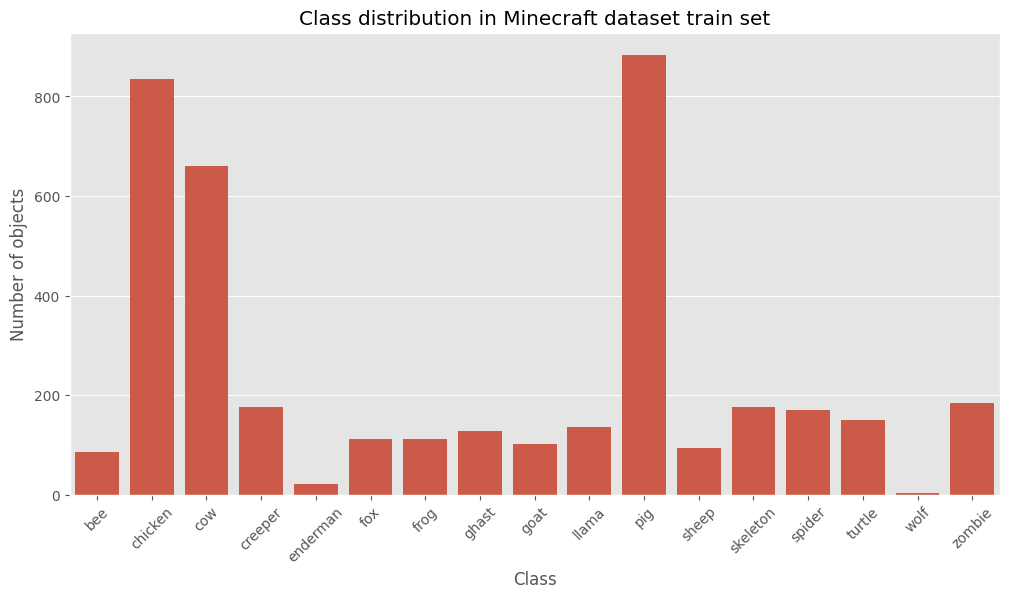

In [10]:
# 7. Распределение классов train

class_counts_train = ann_df_train["category_id"].value_counts().sort_index()

class_names_train = {
    row["id"]: row["name"]
    for _, row in cat_df_train.iterrows()
}

class_labels = [class_names_train[i] for i in class_counts_train.index]

plt.figure(figsize=(12,6))
sns.barplot(x=class_labels, y=class_counts_train.values)

plt.xticks(rotation=45)
plt.title("Class distribution in Minecraft dataset train set")
plt.xlabel("Class")
plt.ylabel("Number of objects")

plt.show()

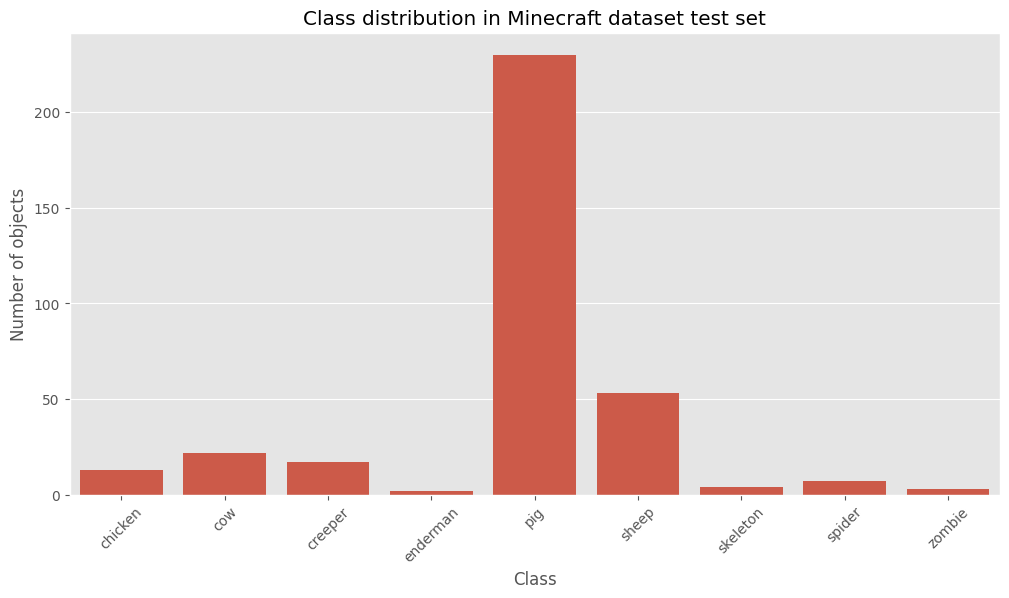

In [11]:
# 8. Распределение классов test

class_counts_test = ann_df_test["category_id"].value_counts().sort_index()

class_names_test = {
    row["id"]: row["name"]
    for _, row in cat_df_test.iterrows()
}

class_labels = [class_names_test[i] for i in class_counts_test.index]

plt.figure(figsize=(12,6))
sns.barplot(x=class_labels, y=class_counts_test.values)

plt.xticks(rotation=45)
plt.title("Class distribution in Minecraft dataset test set")
plt.xlabel("Class")
plt.ylabel("Number of objects")

plt.show()

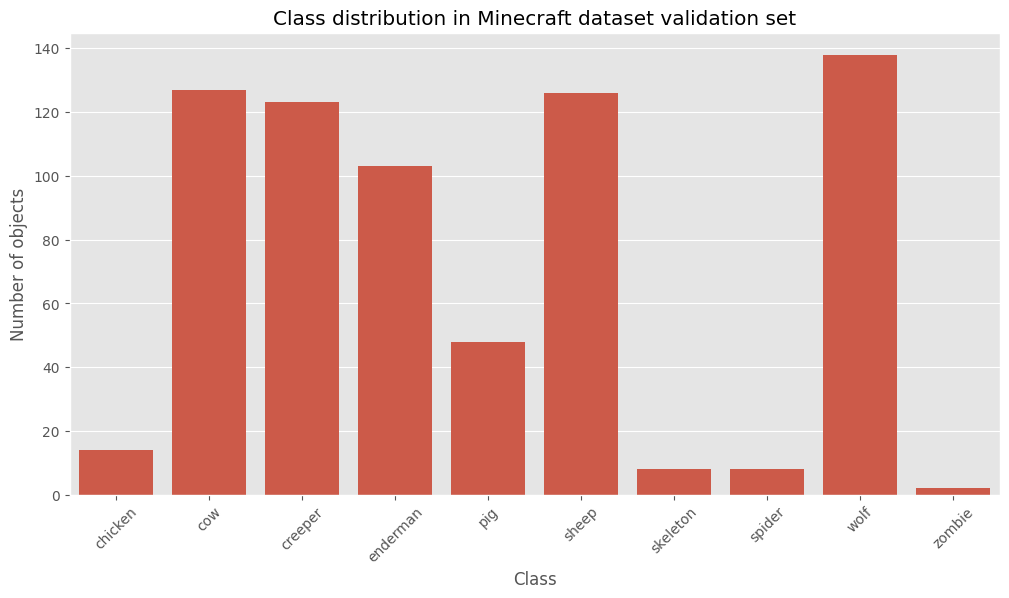

In [12]:
# 9. Распределение классов validation

class_counts_val = ann_df_val["category_id"].value_counts().sort_index()

class_names_val = {
    row["id"]: row["name"]
    for _, row in cat_df_val.iterrows()
}

class_labels = [class_names_val[i] for i in class_counts_val.index]

plt.figure(figsize=(12,6))
sns.barplot(x=class_labels, y=class_counts_val.values)

plt.xticks(rotation=45)
plt.title("Class distribution in Minecraft dataset validation set")
plt.xlabel("Class")
plt.ylabel("Number of objects")

plt.show()

In [17]:
# 8. Анализ дисбаланса классов train
print("Train set imbalance analysis:")
print("Max class count:", class_counts_train.max())
print("Min class count:", class_counts_train.min())

imbalance_ratio = class_counts_train.max() / class_counts_train.min()
print("Imbalance ratio:", imbalance_ratio)

# 10. Анализ дисбаланса классов test
print("\n\nTest set imbalance analysis:")
print("Max class count:", class_counts_test.max())
print("Min class count:", class_counts_test.min())

imbalance_ratio = class_counts_test.max() / class_counts_test.min()
print("Imbalance ratio:", imbalance_ratio)


# 10. Анализ дисбаланса классов test
print("\n\nTrain set imbalance analysis:")
print("Max class count:", class_counts_val.max())
print("Min class count:", class_counts_val.min())

imbalance_ratio = class_counts_val.max() / class_counts_val.min()
print("Imbalance ratio:", imbalance_ratio)

Train set imbalance analysis:
Max class count: 884
Min class count: 4
Imbalance ratio: 221.0


Test set imbalance analysis:
Max class count: 230
Min class count: 2
Imbalance ratio: 115.0


Train set imbalance analysis:
Max class count: 138
Min class count: 2
Imbalance ratio: 69.0


In [18]:
# 9. Визуализация bounding boxes
def draw_boxes(image, boxes, labels):

    image = image.copy()

    for box, label in zip(boxes, labels):

        x, y, w, h = box

        x1 = int(x)
        y1 = int(y)
        x2 = int(x + w)
        y2 = int(y + h)

        cv2.rectangle(image, (x1,y1), (x2,y2), (0,255,0), 2)

        cv2.putText(
            image,
            label,
            (x1, y1-5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0,255,0),
            2
        )

    return image

visualizing sample image with annotations train set:


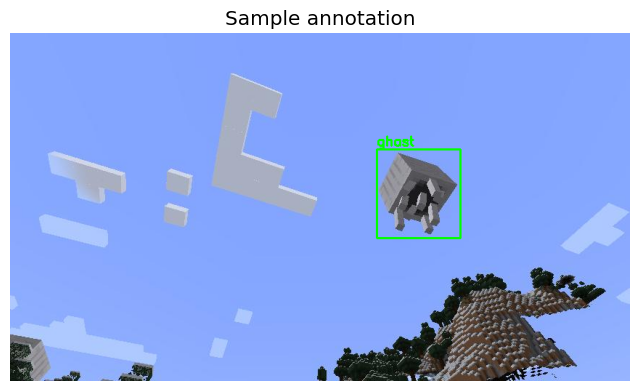

In [19]:
import json

print("visualizing sample image with annotations train set:")

train_ann_path = ann_dir / "annotations_train.json"

with open(train_ann_path, "r") as f:
    train_json = json.load(f)

sample_image_train = images_df_train.sample(1).iloc[0]

img_id = sample_image_train["id"]
file_name = sample_image_train["file_name"]

img_path = train_dir / file_name

image = cv2.imread(str(img_path))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

sample_annotations_train = ann_df_train[ann_df_train["image_id"] == img_id]

boxes = sample_annotations_train["bbox"].tolist()

# mapping id -> name
class_names_train = {
    cat["id"]: cat["name"]
    for cat in train_json["categories"]
}

labels = [
    class_names_train[cid]
    for cid in sample_annotations_train["category_id"]
]

vis_img = draw_boxes(image, boxes, labels)

plt.figure(figsize=(8,8))
plt.imshow(vis_img)
plt.axis("off")
plt.title("Sample annotation")
plt.show()

Вывод: данные имеют сильный дисбаланс, который необходимо устранить след подходом 
4. Обработка дисбаланса классов

Oversampling редких классов:
увеличение количества изображений с редкими объектами
повторное использование изображений с редкими классами

Data augmentation
Для редких классов будет применено больше аугментаций:
повороты
изменение яркости
шум
масштабирование
случайные кропы

4.3 Взвешивание классов
Использование class weights или Focal Loss, чтобы модель больше учитывала редкие классы.


Эти правки будут вноиться только после того как вообще получится что то сделать 
Изначально все будет делать в базовой конфигурации чтобы вообще добиться хоть какой то работы

Этап 3. Настройка конфигурации моделей
Модель в файле configs/fcos/fcos_minecraft.py

Отрисовка на базовой конфигурации модели - без обучения 

/home/ubuntu/mmdetection/mmdet/apis/inference.py:70: UserWarning: checkpoint is None, use COCO classes by default.
  warnings.warn('checkpoint is None, use COCO classes by default.')


Backbone weights загружены, bbox_head готов к обучению на 17 классов


/home/ubuntu/practicum_venv/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3526.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Inference сохранён в artifacts/inference/test_pretrained.jpg


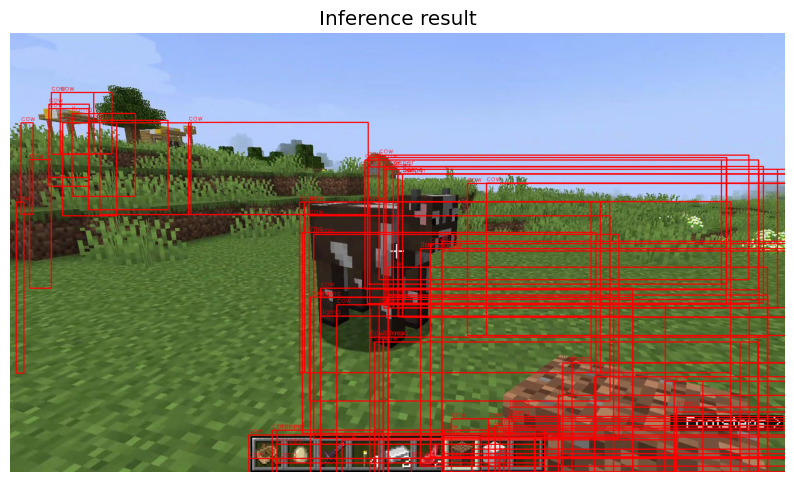

In [21]:
# === Imports ===
import torch
from pathlib import Path
import mmcv
import cv2
import matplotlib.pyplot as plt
from mmdet.apis import init_detector, inference_detector

# Функция для отрисовки bbox и labels на изображении
def draw_boxes(image, boxes, labels, color=(255,0,0), thickness=2):
    img = image.copy()
    for bbox, label in zip(boxes, labels):
        x1, y1, w, h = bbox
        x2, y2 = int(x1 + w), int(y1 + h)
        cv2.rectangle(img, (int(x1), int(y1)), (x2, y2), color, thickness)
        cv2.putText(img, label, (int(x1), int(y1)-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 1)
    return img

# === Конфиг и checkpoint ===
config_file = 'configs/fcos/fcos_minecraft.py'
checkpoint_file = 'checkpoints/fcos_r50_caffe_fpn_gn-head_1x_coco-821213aa.pth'  # COCO pretrained

# === Проверяем изображение для теста ===
img_path = Path("datasets/minecraft/valid/images/tree-extracted00045_png.rf.cb6c69fe62a53e198b7c6d0d0aa99bb6.jpg")
assert img_path.exists(), f"{img_path} не найден!"

# === Инициализация модели на CPU ===
model = init_detector(config_file, device='cpu')

# === Загружаем pretrained веса backbone, исключая bbox_head ===
checkpoint = torch.load(checkpoint_file, map_location='cpu')['state_dict']
filtered_ckpt = {k: v for k, v in checkpoint.items() if not k.startswith('bbox_head')}
model.load_state_dict(filtered_ckpt, strict=False)
print("Backbone weights загружены, bbox_head готов к обучению на 17 классов")

# === Инференс ===
result = inference_detector(model, str(img_path))

# === Преобразуем результат в boxes и labels для matplotlib ===
# result — это DetDataSample, поэтому используем bbox и labels
# result.pred_instances.bboxes: tensor N x 4
# result.pred_instances.labels: tensor N
bboxes = result.pred_instances.bboxes.cpu().numpy()
labels_idx = result.pred_instances.labels.cpu().numpy()

# Названия классов (17 Minecraft)
CLASSES = (
    'bee', 'chicken', 'cow', 'creeper', 'enderman', 'fox', 'frog', 'ghast',
    'goat', 'llama', 'pig', 'sheep', 'skeleton', 'spider', 'turtle', 'wolf', 'zombie'
)
labels = [CLASSES[i] for i in labels_idx]

# === Загружаем изображение через cv2 и конвертируем в RGB ===
image = cv2.imread(str(img_path))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# === Отрисовываем bounding boxes ===
vis_img = draw_boxes(image, bboxes, labels)

# === Сохраняем визуализацию ===
out_file = Path("artifacts/inference/test_pretrained.jpg")
out_file.parent.mkdir(parents=True, exist_ok=True)
mmcv.imwrite(vis_img, str(out_file))
print(f"Inference сохранён в {out_file}")

# === Показываем результат через matplotlib ===
plt.figure(figsize=(10,10))
plt.imshow(vis_img)
plt.axis("off")
plt.title("Inference result")
plt.show()

Этап 4. Обучение моделей
Конфиг Модели в файле configs/fcos/fcos_minecraft.py

Ниже обучение модели FCOS(закомментировал чтобы не запустить повторно), обучение yolo в файле train_yolo_minecraft и оценка yolo в файле evaluate.yolo 

In [ ]:
# from mmengine.config import Config
# from mmdet.registry import RUNNERS

# config_file = "configs/fcos/fcos_minecraft.py"

# cfg = Config.fromfile(config_file)

# cfg.work_dir = "./artifacts"

# # обучение на CPU
# cfg.device = "cuda"

# runner = RUNNERS.build(cfg)

# runner.train()

03/09 08:24:48 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.10.12 (main, Aug 15 2025, 14:32:43) [GCC 11.4.0]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 2018917718
    GPU 0: Tesla T4
    CUDA_HOME: /usr
    NVCC: Cuda compilation tools, release 12.2, V12.2.140
    GCC: x86_64-linux-gnu-gcc (Ubuntu 11.4.0-1ubuntu1~22.04.2) 11.4.0
    PyTorch: 2.1.0+cu121
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2022.2-Product Build 20220804 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v3.1.1 (Git Hash 64f6bcbcbab628e96f33a62c3e975f8535a7bde4)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX512
  - CUDA Runtime 12.1
  - NVCC architecture flags: -gencode;arch=compute_50,code=sm_50;-ge

/home/ubuntu/practicum_venv/lib/python3.10/site-packages/mmengine/utils/manager.py:113: UserWarning: <class 'mmdet.visualization.local_visualizer.DetLocalVisualizer'> instance named of visualizer has been created, the method `get_instance` should not accept any other arguments
  warnings.warn(


03/09 08:24:48 - mmengine - INFO - Distributed training is not used, all SyncBatchNorm (SyncBN) layers in the model will be automatically reverted to BatchNormXd layers if they are used.
03/09 08:24:48 - mmengine - INFO - Hooks will be executed in the following order:
before_run:
(VERY_HIGH   ) RuntimeInfoHook                    
(BELOW_NORMAL) LoggerHook                         
 -------------------- 
before_train:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(VERY_LOW    ) CheckpointHook                     
 -------------------- 
before_train_epoch:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(NORMAL      ) DistSamplerSeedHook                
 -------------------- 
before_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
 -------------------- 
after_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                

FCOS(
  (data_preprocessor): DetDataPreprocessor()
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): ResLayer(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
   

ОТРИСОВКА топ 5 для FCOS

Loads checkpoint by local backend from path: artifacts/epoch_12.pth


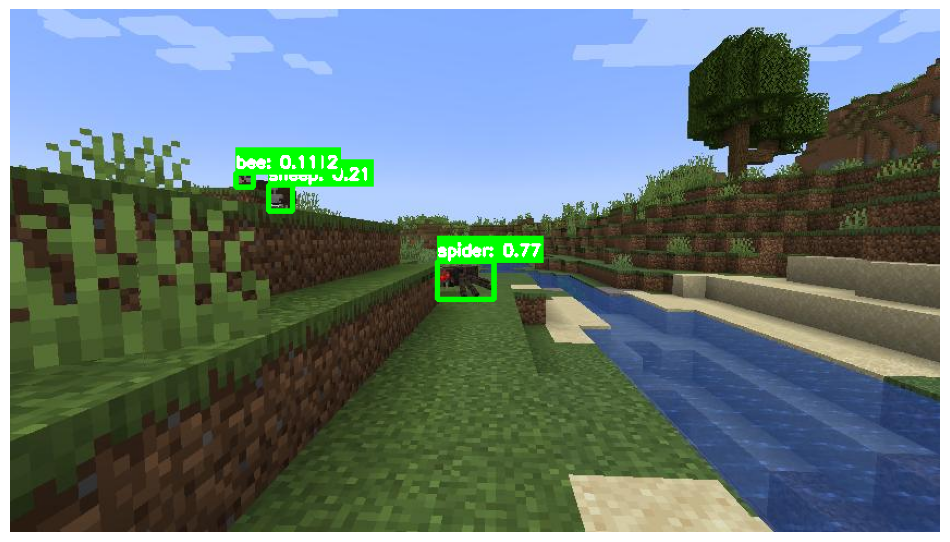

Saved to artifacts/inference/fcos/test_pretrained_top5_img1.jpg


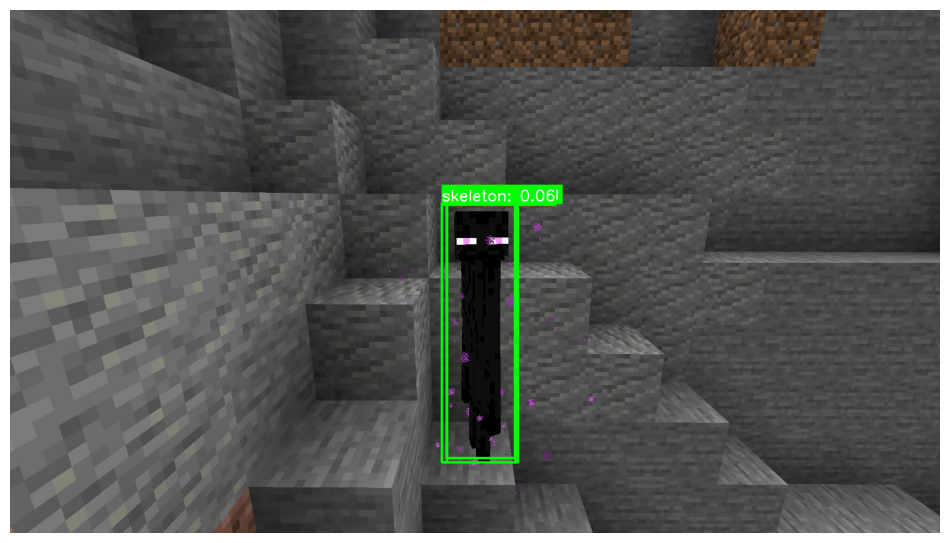

Saved to artifacts/inference/fcos/test_pretrained_top5_img2.jpg


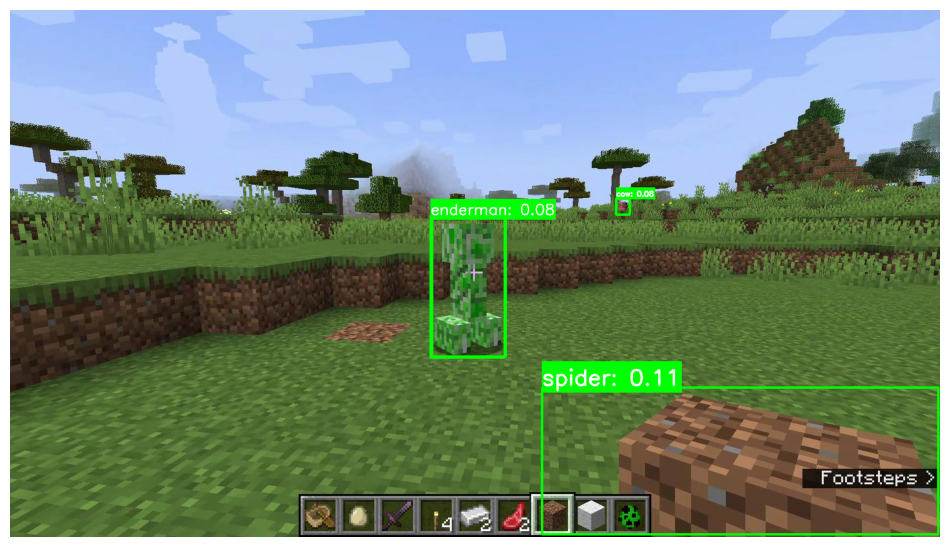

Saved to artifacts/inference/fcos/test_pretrained_top5_img3.jpg


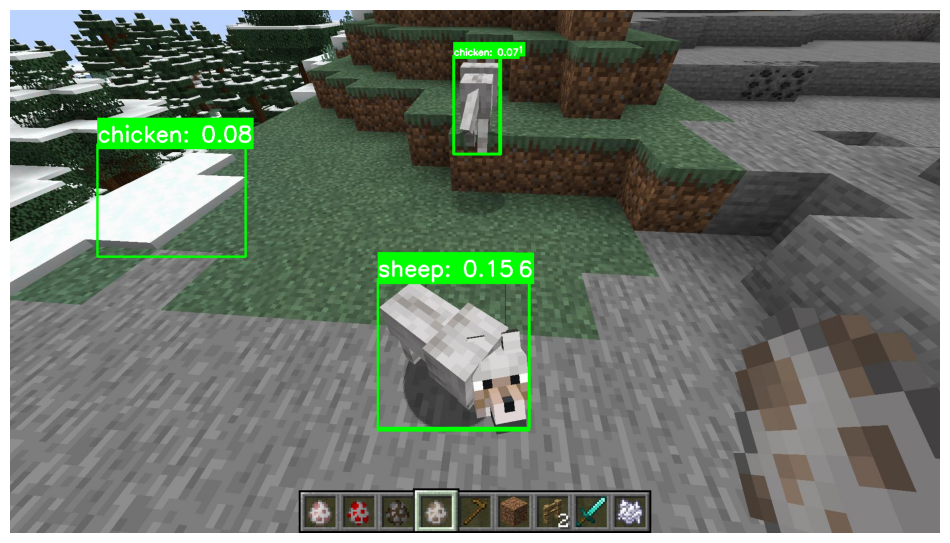

Saved to artifacts/inference/fcos/test_pretrained_top5_img4.jpg


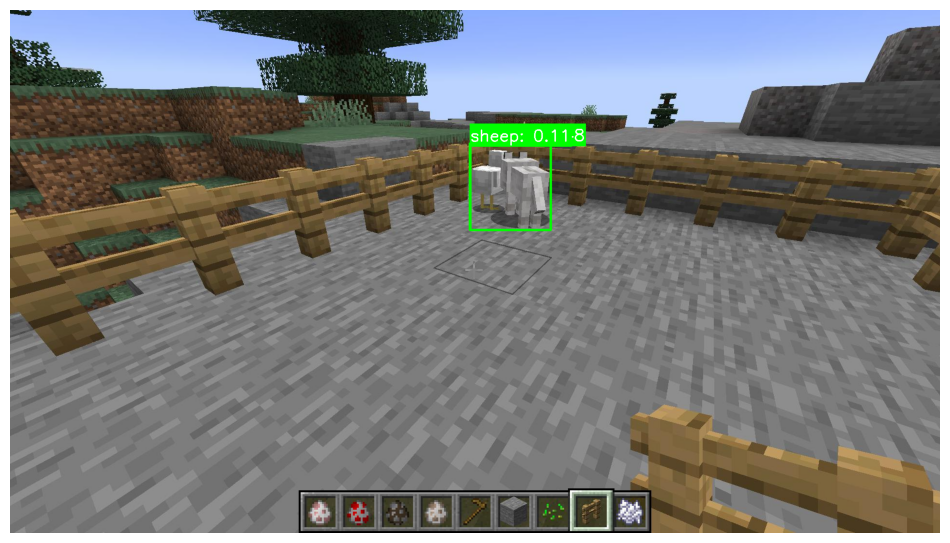

Saved to artifacts/inference/fcos/test_pretrained_top5_img5.jpg


In [33]:
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
from mmengine.config import Config
from mmdet.apis import init_detector, inference_detector

# -----------------------------
# Конфиг и чекпоинт
# -----------------------------
config_file = "configs/fcos/fcos_minecraft.py"
# checkpoint = "artifacts/20260309_082448/epoch_12.pth"
checkpoint = "artifacts/epoch_12.pth"
cfg = Config.fromfile(config_file)
model = init_detector(cfg, checkpoint=checkpoint, device="cpu")

# -----------------------------
# Папка с изображениями валидации
# -----------------------------
img_folder = "datasets/minecraft/valid/images"
img_paths = glob.glob(os.path.join(img_folder, "*.jpg"))[:5]  # берем первые 5

CLASSES = (
    'bee','chicken','cow','creeper','enderman','fox','frog','ghast',
    'goat','llama','pig','sheep','skeleton','spider','turtle','wolf','zombie'
)
TOP_K = 5
CONF_THRESH = 0.05

# -----------------------------
# Функция отрисовки боксов
# -----------------------------
def draw_boxes(image, boxes, labels, scores, top_k=TOP_K, conf_thresh=CONF_THRESH):
    img = image.copy()
    if len(scores) > 0:
        mask = scores > conf_thresh
        boxes, labels, scores = boxes[mask], labels[mask], scores[mask]
        top_idx = np.argsort(scores)[-top_k:][::-1]
        boxes, labels, scores = boxes[top_idx], labels[top_idx], scores[top_idx]

    for bbox, label, score in zip(boxes, labels, scores):
        x1, y1, x2, y2 = bbox.astype(int)

        # цвет рамки
        color = (0, 255, 0)

        # отрисовка бокса
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)

        # текст с контуром
        text = f"{CLASSES[label]}: {score:.2f}"

        # адаптивный шрифт
        box_width = x2 - x1
        font_scale = max(0.5, min(1.5, box_width / 150))
        thickness = max(2, int(font_scale * 2))

        # получаем размер текста
        (text_w, text_h), baseline = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, font_scale, thickness)

        # координаты текста
        text_x, text_y = x1, max(y1 - 5, text_h + 5)

        # фон для текста
        cv2.rectangle(img, (text_x, text_y - text_h - baseline), (text_x + text_w, text_y + baseline), color, cv2.FILLED)
        cv2.putText(img, text, (text_x, text_y), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 255, 255), thickness)

    return img

# -----------------------------
# Создаем папку для сохранения
# -----------------------------
save_folder = "artifacts/inference/fcos"
os.makedirs(save_folder, exist_ok=True)

# -----------------------------
# Инференс и сохранение top-5 изображений
# -----------------------------
for i, img_path in enumerate(img_paths):
    image = cv2.imread(img_path)
    # print(f'image : {image}')
    result = inference_detector(model, img_path)

    bboxes = result.pred_instances.bboxes.cpu().numpy()
    labels = result.pred_instances.labels.cpu().numpy()
    scores = result.pred_instances.scores.cpu().numpy()

    # print("Boxes:", bboxes.shape)
    # print("Scores:", scores)
    # print("Labels:", labels)

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    vis_img = draw_boxes(image_rgb, bboxes, labels, scores, top_k=TOP_K)

    # отображение
    plt.figure(figsize=(12,12))
    plt.imshow(vis_img)
    plt.axis("off")
    plt.show()

    # сохранение
    save_path = os.path.join(save_folder, f"test_pretrained_top5_img{i+1}.jpg")
    cv2.imwrite(save_path, cv2.cvtColor(vis_img, cv2.COLOR_RGB2BGR))
    print(f"Saved to {save_path}")

Тестовая отрисовка для yolo - до обучения 

/home/ubuntu/practicum_venv/lib/python3.10/site-packages/thop/profile.py:12: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(torch.__version__) < LooseVersion("1.0.0"):

Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /home/ubuntu/mmdetection/bus.jpg: 640x480 4 persons, 1 bus, 55.1ms
Speed: 2.0ms preprocess, 55.1ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 480)


Boxes: ultralytics.engine.results.Boxes object with attributes:

cls: tensor([5., 0., 0., 0., 0.], device='cuda:0')
conf: tensor([0.9213, 0.8929, 0.8865, 0.8778, 0.6114], device='cuda:0')
data: tensor([[1.4999e+01, 2.2849e+02, 8.0818e+02, 7.4812e+02, 9.2129e-01, 5.0000e+00],
        [6.6730e+02, 3.8965e+02, 8.0967e+02, 8.7852e+02, 8.9290e-01, 0.0000e+00],
        [4.9882e+01, 4.0185e+02, 2.4454e+02, 9.0179e+02, 8.8650e-01, 0.0000e+00],
        [2.2212e+02, 4.0819e+02, 3.4548e+02, 8.6069e+02, 8.7779e-01, 0.0000e+00],
        [1.6442e-01, 5.5082e+02, 6.5177e+01, 8.6900e+02, 6.1136e-01, 0.0000e+00]], device='cuda:0')
id: None
is_track: False
orig_shape: (1080, 810)
shape: torch.Size([5, 6])
xywh: tensor([[411.5918, 488.3044, 793.1846, 519.6326],
        [738.4844, 634.0839, 142.3636, 488.8748],
        [147.2089, 651.8195, 194.6529, 499.9478],
        [283.7957, 634.4384, 123.3587, 452.4956],
        [ 32.6708, 709.9102,  65.0128, 318.1794]], device='cuda:0')
xywhn: tensor([[0.5081, 0.452

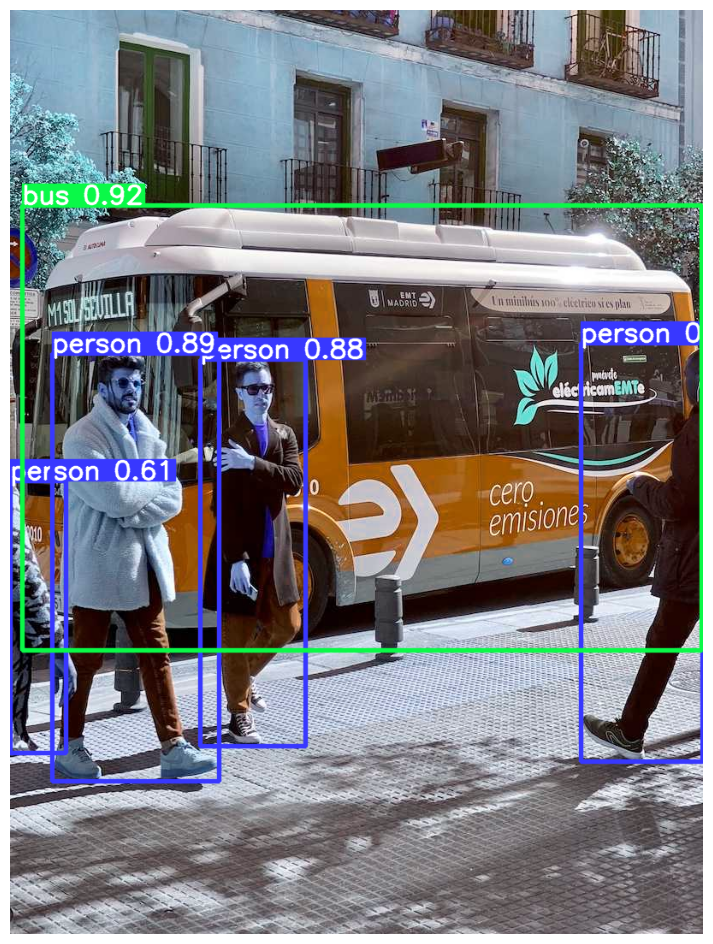

In [46]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

# Загружаем модель
model = YOLO("yolov8s.pt")  # или твой путь к весам

# URL изображения
img_path = "https://ultralytics.com/images/bus.jpg"

# Инференс (одно изображение)
results = model.predict(img_path, conf=0.25)

# Результаты
print("Boxes:", results[0].boxes)
print("Detections:", len(results[0].boxes))

# Визуализация
result_img = results[0].plot()
plt.figure(figsize=(12,12))
plt.imshow(result_img)
plt.axis("off")
plt.show()

Для yolo нужно создать аннтоации - тут закомментировано так как создал локально и скопировал с датасетом

In [ ]:
# import json
# import os
# import cv2
# from pathlib import Path

# # --- Настройки ---
# dataset_root = "datasets/minecraft"  # корень с папками train, valid, test
# splits = ["train", "valid", "test"]
# annotations_files = {
#     "train": "annotations/annotations_train.json",
#     "valid": "annotations/annotations_valid.json",
#     "test": "annotations/annotations_test.json"
# }

# # --- Функция конвертации COCO -> YOLO ---
# def convert_coco_to_yolo(images_dir, json_file, save_dir):
#     os.makedirs(save_dir, exist_ok=True)

#     if not os.path.exists(images_dir):
#         print(f"[ERROR] Папка с изображениями не найдена: {images_dir}")
#         return
#     if not os.path.exists(json_file):
#         print(f"[ERROR] JSON файл не найден: {json_file}")
#         return

#     # Берем только изображения, фильтруем системные файлы
#     img_files = [f for f in os.listdir(images_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
#     if len(img_files) == 0:
#         print(f"[WARN] Папка {images_dir} пуста или нет изображений!")
#         return
#     else:
#         print(f"[INFO] Найдено {len(img_files)} изображений в {images_dir}")

#     with open(json_file, "r", encoding="utf-8") as f:
#         data = json.load(f)

#     # mapping: category_id -> 0..N-1
#     categories = {c['id']: idx for idx, c in enumerate(data['categories'])}

#     for img_info in data['images']:
#         file_name = img_info['file_name']
#         img_path = os.path.join(images_dir, file_name)

#         # Проверяем, есть ли файл среди реальных изображений
#         if file_name not in img_files:
#             continue

#         img = cv2.imread(img_path)
#         h, w = img.shape[:2]

#         annots = [a for a in data['annotations'] if a['image_id'] == img_info['id']]

#         lines = []
#         for a in annots:
#             cat_id = categories[a['category_id']]
#             x, y, bw, bh = a['bbox']

#             # YOLO: центр + нормализация
#             cx = (x + bw / 2) / w
#             cy = (y + bh / 2) / h
#             nw = bw / w
#             nh = bh / h
#             lines.append(f"{cat_id} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}")

#         txt_name = Path(file_name).stem + ".txt"
#         txt_path = os.path.join(save_dir, txt_name)
#         with open(txt_path, "w", encoding="utf-8") as f:
#             f.write("\n".join(lines))

# # --- Конвертация всех сплитов ---
# for split in splits:
#     images_dir = os.path.join(dataset_root, split)
#     json_file = os.path.join(dataset_root, annotations_files[split])
#     save_dir = os.path.join(dataset_root, f"{split}_yolo")  # отдельная папка для .txt

#     print(f"\n--- Converting {split} set ---")
#     print(f"Images folder: {images_dir}")
#     print(f"JSON file: {json_file}")
#     print(f"Saving YOLO txt to: {save_dir}")

#     convert_coco_to_yolo(images_dir, json_file, save_dir)
#     print(f"Finished {split}, check folder {save_dir}")



# print(f"\ndata.yaml created at {data_yaml_path}")
# for split in splits:
#     ann_dir = os.path.join(dataset_root, f"{split}_yolo")
#     txt_files = os.listdir(ann_dir)
#     print(f"{split}_yolo: {len(txt_files)} .txt файлов")



Отрисовка топ 5 для yolo 

Используем веса: artifacts/yolo_minecraft_cuda5/weights/best.pt


image 1/1 /home/ubuntu/mmdetection/datasets/minecraft/valid/images/2023-04-03_19_21_28_png.rf.a081597f4c5bf925b9022b9dd72462a6.jpg: 288x512 1 spider, 51.7ms
Speed: 1.0ms preprocess, 51.7ms inference, 1.3ms postprocess per image at shape (1, 3, 288, 512)


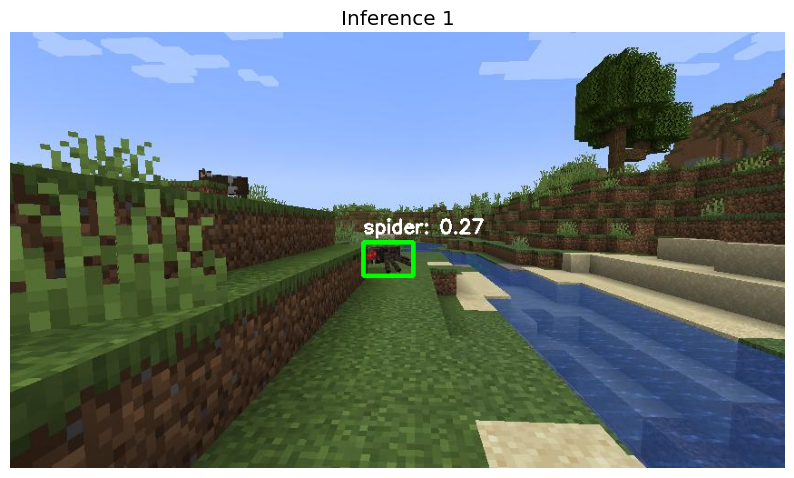


image 1/1 /home/ubuntu/mmdetection/datasets/minecraft/valid/images/enderman-91-_png.rf.4c5908c2a38fcb8aac83a188f67768e5.jpg: 288x512 1 enderman, 8.7ms
Speed: 1.1ms preprocess, 8.7ms inference, 1.2ms postprocess per image at shape (1, 3, 288, 512)


Saved artifacts/inference/yolo_minecraft/inference_1.jpg


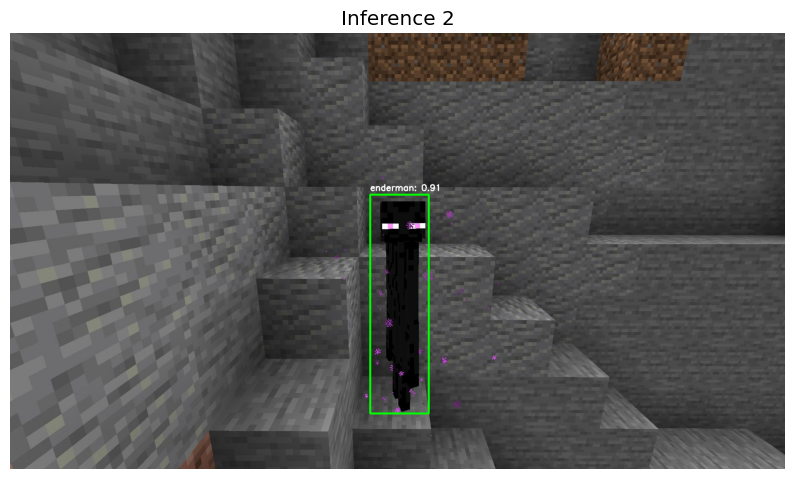


image 1/1 /home/ubuntu/mmdetection/datasets/minecraft/valid/images/creeper00079_png.rf.7c2e059452ec2c0b7339700cb3fdcb69.jpg: 320x512 1 creeper, 59.6ms
Speed: 1.4ms preprocess, 59.6ms inference, 1.1ms postprocess per image at shape (1, 3, 320, 512)


Saved artifacts/inference/yolo_minecraft/inference_2.jpg


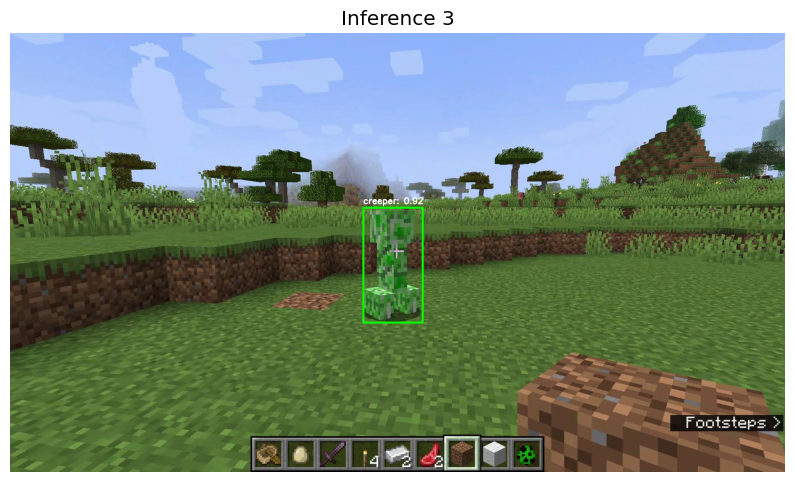


image 1/1 /home/ubuntu/mmdetection/datasets/minecraft/valid/images/Minecraft-1-19-2-2022-11-29-4_07_12_png.rf.20ddfb7d25701095d4c202804ab5f895.jpg: 288x512 1 chicken, 1 sheep, 10.2ms
Speed: 1.1ms preprocess, 10.2ms inference, 1.5ms postprocess per image at shape (1, 3, 288, 512)


Saved artifacts/inference/yolo_minecraft/inference_3.jpg


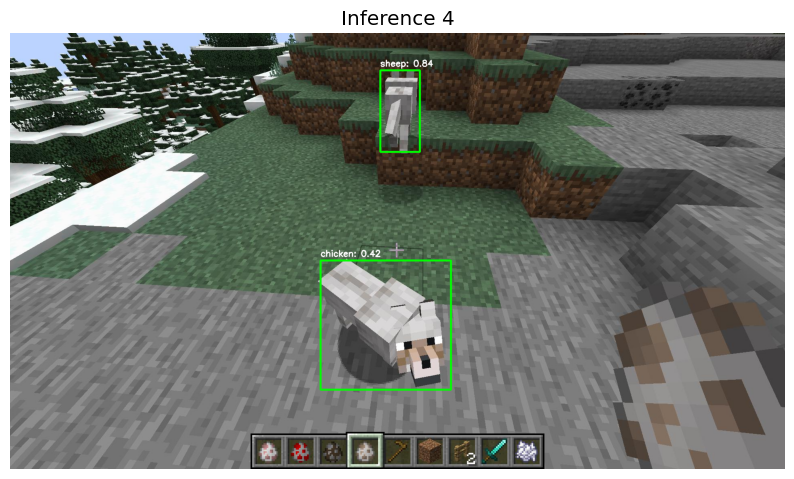


image 1/1 /home/ubuntu/mmdetection/datasets/minecraft/valid/images/Minecraft-1-19-2-2022-11-29-3_44_01_png.rf.ab9bc44577337769e2b9da0bc4e3d6c8.jpg: 288x512 1 goat, 9.3ms
Speed: 1.7ms preprocess, 9.3ms inference, 1.1ms postprocess per image at shape (1, 3, 288, 512)


Saved artifacts/inference/yolo_minecraft/inference_4.jpg


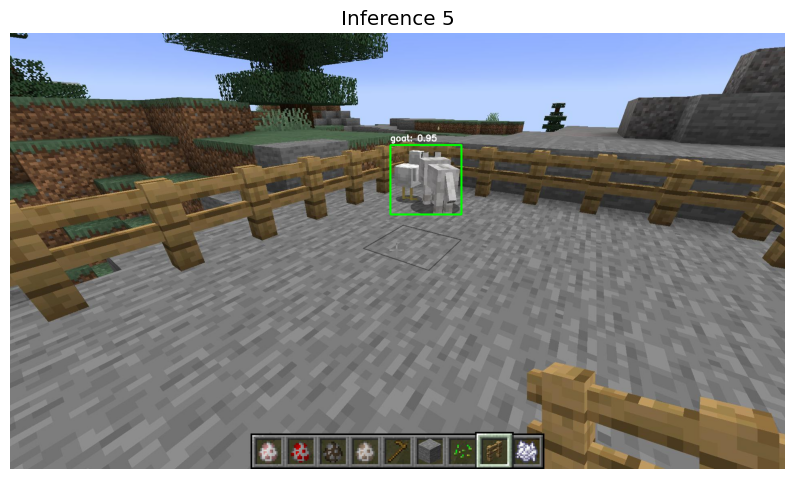

Saved artifacts/inference/yolo_minecraft/inference_5.jpg


In [49]:
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
%matplotlib inline
import matplotlib.pyplot as plt
# -----------------------------
# Путь к последним весам YOLO
# -----------------------------
weights_dir = "artifacts/yolo_minecraft_cuda5/weights"
best_weight = os.path.join(weights_dir, "best.pt")
if not os.path.exists(best_weight):
    raise FileNotFoundError(f"Файл best.pt не найден в {weights_dir}")
print(f"Используем веса: {best_weight}")

# -----------------------------
# Загружаем модель
# -----------------------------
model = YOLO(best_weight)

# -----------------------------
# Папка с изображениями валидации
# -----------------------------
img_folder = "datasets/minecraft/valid/images"
img_paths = glob.glob(os.path.join(img_folder, "*.jpg"))[:5]  # берем первые 5 изображений

CLASSES = (
    'bee','chicken','cow','creeper','enderman','fox','frog','ghast',
    'goat','llama','pig','sheep','skeleton','spider','turtle','wolf','zombie'
)
TOP_K = 5
CONF_THRESH = 0.05

# -----------------------------
# Функция отрисовки боксов
# -----------------------------
def draw_boxes(image, results, top_k=TOP_K, conf_thresh=CONF_THRESH):
    img = image.copy()
    if len(results) == 0:
        return img

    # results[0].boxes: xyxy, conf, cls
    xyxy = results[0].boxes.xyxy.cpu().numpy()
    conf = results[0].boxes.conf.cpu().numpy()
    cls = results[0].boxes.cls.cpu().numpy().astype(int)

    mask = conf > conf_thresh
    xyxy, cls, conf = xyxy[mask], cls[mask], conf[mask]

    top_idx = conf.argsort()[-top_k:][::-1]
    xyxy, cls, conf = xyxy[top_idx], cls[top_idx], conf[top_idx]

    for box, label, score in zip(xyxy, cls, conf):
        x1, y1, x2, y2 = box.astype(int)
        color = (0, 255, 0)
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)
        text = f"{CLASSES[label]}: {score:.2f}"
        cv2.putText(img, text, (x1, max(y1-10, 0)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2)
    return img

# -----------------------------
# Папка для сохранения инференса
# -----------------------------
save_folder = "artifacts/inference/yolo_minecraft"
os.makedirs(save_folder, exist_ok=True)

# -----------------------------
# Инференс и сохранение первых 5 изображений
# -----------------------------
for i, img_path in enumerate(img_paths):
    image = cv2.imread(img_path)
    results = model(img_path)  # инференс

    vis_img = draw_boxes(image, results)

    # отображение
    plt.figure(figsize=(10,10))
    plt.imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"Inference {i+1}")
    plt.show()

    # сохранение
    save_path = os.path.join(save_folder, f"inference_{i+1}.jpg")
    cv2.imwrite(save_path, vis_img)
    print(f"Saved {save_path}")

Обработка видео для yolo

In [51]:
import os
import glob
import cv2
import numpy as np
from ultralytics import YOLO
from tqdm import tqdm

# -----------------------------
# Параметры
# -----------------------------
video_path = "datasets/minecraft/video.mp4"
output_video = "artifacts/videos/yolo_inference.mp4"
os.makedirs(os.path.dirname(output_video), exist_ok=True)

CONF_THRESH = 0.05  # порог уверенности
TOP_K = 5           # отрисовывать top-K предсказаний
CLASSES = (
    'bee','chicken','cow','creeper','enderman','fox','frog','ghast',
    'goat','llama','pig','sheep','skeleton','spider','turtle','wolf','zombie'
)

# -----------------------------
# Функция отрисовки боксов
# -----------------------------
def draw_boxes(frame, boxes, labels, scores, top_k=TOP_K):
    if len(scores) > 0:
        top_idx = np.argsort(scores)[-top_k:][::-1]
        boxes = boxes[top_idx]
        labels = labels[top_idx].astype(int)  # <-- конвертируем в int
        scores = scores[top_idx]

    img = frame.copy()
    for bbox, label, score in zip(boxes, labels, scores):
        x1, y1, x2, y2 = bbox.astype(int)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 3)
        text = f"{CLASSES[label]} {score:.2f}"
        cv2.putText(img, text, (x1, max(y1-10,0)), cv2.FONT_HERSHEY_SIMPLEX,
                    1.0, (0, 0, 255), 2, cv2.LINE_AA)
    return img

# -----------------------------
# Автоматический поиск весов YOLO
# -----------------------------

weights_dir = "artifacts/yolo_minecraft_cuda5/weights"
best_weight = os.path.join(weights_dir, "best.pt")

if not weights_dir:
    raise FileNotFoundError("Не найдены папки с весами YOLO")
weights_dir = sorted(weights_dir)[-1]  # берем последнюю по имени


print(f"Используем веса: {best_weight}")

# -----------------------------
# Загружаем модель
# -----------------------------
model = YOLO(best_weight)

# -----------------------------
# Чтение видео и запись результата
# -----------------------------
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise RuntimeError(f"Не удалось открыть видео {video_path}")

frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_video, fourcc, fps, (frame_width, frame_height))

# -----------------------------
# Инференс по кадрам
# -----------------------------
for i in tqdm(range(total_frames), desc="YOLO Video Inference"):
    ret, frame = cap.read()
    if not ret:
        break

    results = model.predict(frame, imgsz=640, conf=CONF_THRESH)
    boxes, scores, labels = [], [], []
    for r in results:
        if len(r.boxes) > 0:
            boxes.append(r.boxes.xyxy.cpu().numpy())
            scores.append(r.boxes.conf.cpu().numpy())
            labels.append(r.boxes.cls.cpu().numpy())
    if boxes:
        boxes = np.concatenate(boxes)
        scores = np.concatenate(scores)
        labels = np.concatenate(labels)
    else:
        boxes = np.zeros((0,4))
        scores = np.zeros(0)
        labels = np.zeros(0)

    vis_frame = draw_boxes(frame, boxes, labels, scores, top_k=TOP_K)
    out.write(vis_frame)

cap.release()
out.release()
print(f"Видео с результатами YOLO сохранено в {output_video}")

Используем веса: artifacts/yolo_minecraft_cuda5/weights/best.pt


YOLO Video Inference:   0%|          | 0/756 [00:00<?, ?it/s]
0: 320x640 1 cow, 1 skeleton, 21.2ms
Speed: 3.3ms preprocess, 21.2ms inference, 1.4ms postprocess per image at shape (1, 3, 320, 640)
YOLO Video Inference:   0%|          | 1/756 [00:00<06:41,  1.88it/s]
0: 320x640 1 cow, 1 sheep, 1 skeleton, 11.1ms
Speed: 2.7ms preprocess, 11.1ms inference, 1.6ms postprocess per image at shape (1, 3, 320, 640)
YOLO Video Inference:   0%|          | 2/756 [00:00<03:53,  3.23it/s]
0: 320x640 1 sheep, 1 skeleton, 10.6ms
Speed: 2.5ms preprocess, 10.6ms inference, 1.2ms postprocess per image at shape (1, 3, 320, 640)

0: 320x640 1 cow, 1 sheep, 1 skeleton, 10.5ms
Speed: 2.1ms preprocess, 10.5ms inference, 1.1ms postprocess per image at shape (1, 3, 320, 640)
YOLO Video Inference:   1%|          | 4/756 [00:00<01:51,  6.74it/s]
0: 320x640 1 cow, 1 sheep, 1 skeleton, 10.5ms
Speed: 1.7ms preprocess, 10.5ms inference, 1.1ms postprocess per image at shape (1, 3, 320, 640)

0: 320x640 1 cow, 1 sheep, 

Видео с результатами YOLO сохранено в artifacts/videos/yolo_inference.mp4


Обработка ВИДЕО ДЛЯ FCOS

In [34]:
import os
import cv2
import numpy as np
from mmengine.config import Config
from mmdet.apis import init_detector, inference_detector
from tqdm import tqdm

# -----------------------------
# Параметры
# -----------------------------
config_file = "configs/fcos/fcos_minecraft.py"
checkpoint = "artifacts/epoch_12.pth"
video_path = "datasets/minecraft/video.mp4"
output_video = "artifacts/videos/fcos_inference.mp4"
os.makedirs("artifacts/videos", exist_ok=True)

CONF_THRESH = 0.05  # порог уверенности
TOP_K = 5           # отрисовывать топ-K предсказаний
CLASSES = (
    'bee','chicken','cow','creeper','enderman','fox','frog','ghast',
    'goat','llama','pig','sheep','skeleton','spider','turtle','wolf','zombie'
)

# -----------------------------
# Функция отрисовки боксов
# -----------------------------
def draw_boxes(frame, bboxes, labels, scores, top_k=TOP_K):
    # сортируем по уверенности и берем top_k
    if len(scores) > 0:
        top_idx = np.argsort(scores)[-top_k:][::-1]
        bboxes = bboxes[top_idx]
        labels = labels[top_idx]
        scores = scores[top_idx]
    img = frame.copy()
    for bbox, label, score in zip(bboxes, labels, scores):
        x1, y1, x2, y2 = bbox.astype(int)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 3)
        text = f"{CLASSES[label]} {score:.2f}"
        cv2.putText(img, text, (x1, max(y1-10, 0)), cv2.FONT_HERSHEY_SIMPLEX,
                    1.0, (0, 0, 255), 2, cv2.LINE_AA)
    return img

# -----------------------------
# Загружаем модель
# -----------------------------
cfg = Config.fromfile(config_file)
model = init_detector(cfg, checkpoint=checkpoint, device="cpu")

# -----------------------------
# Чтение видео и создание записи
# -----------------------------
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise RuntimeError(f"Не удалось открыть видео {video_path}")

frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_video, fourcc, fps, (frame_width, frame_height))

# -----------------------------
# Инференс по кадрам
# -----------------------------
for i in tqdm(range(total_frames), desc="FCOS Video Inference"):
    ret, frame = cap.read()
    if not ret:
        break

    # инференс
    result = inference_detector(model, frame)
    bboxes = result.pred_instances.bboxes.cpu().numpy()
    labels = result.pred_instances.labels.cpu().numpy()
    scores = result.pred_instances.scores.cpu().numpy()

    # фильтр по порогу уверенности
    mask = scores > CONF_THRESH
    bboxes, labels, scores = bboxes[mask], labels[mask], scores[mask]

    # отрисовка
    vis_frame = draw_boxes(frame, bboxes, labels, scores, top_k=TOP_K)
    out.write(vis_frame)

cap.release()
out.release()
print(f"Видео с результатами сохранено в {output_video}")

Loads checkpoint by local backend from path: artifacts/epoch_12.pth


FCOS Video Inference: 100%|██████████| 756/756 [18:25<00:00,  1.46s/it]

Видео с результатами сохранено в artifacts/videos/fcos_inference.mp4


отрисовка графика для FCOS

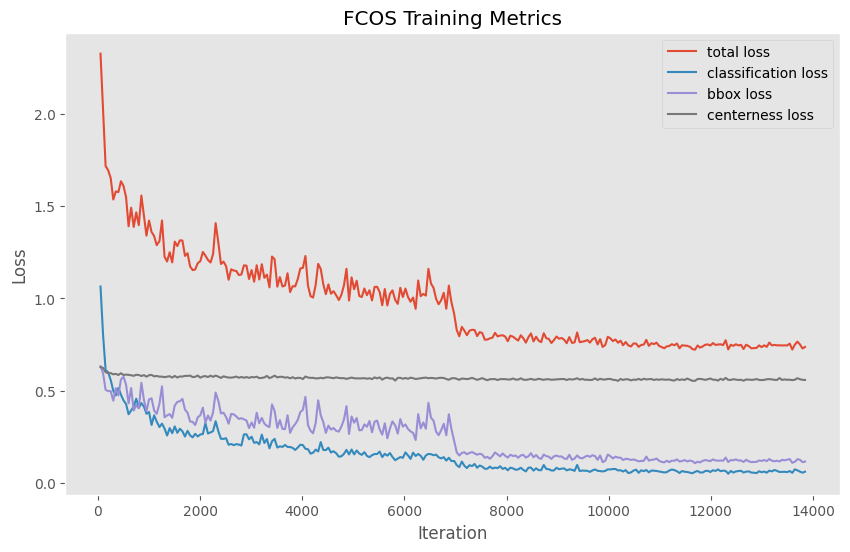

In [36]:
import json
import matplotlib.pyplot as plt

log_file = "artifacts/20260309_081543/vis_data/scalars.json"

iters = []
loss = []
loss_cls = []
loss_bbox = []
loss_centerness = []

with open(log_file) as f:
    for line in f:
        data = json.loads(line)

        if "loss" in data:
            iters.append(data["iter"])
            loss.append(data["loss"])
            loss_cls.append(data["loss_cls"])
            loss_bbox.append(data["loss_bbox"])
            loss_centerness.append(data["loss_centerness"])

plt.figure(figsize=(10,6))

plt.plot(iters, loss, label="total loss")
plt.plot(iters, loss_cls, label="classification loss")
plt.plot(iters, loss_bbox, label="bbox loss")
plt.plot(iters, loss_centerness, label="centerness loss")

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("FCOS Training Metrics")
plt.legend()
plt.grid()

plt.show()

Проверка метрик FCOS

In [37]:
import pandas as pd
import os
import time

from mmengine.config import Config
from mmdet.registry import RUNNERS

cfg_file = "configs/fcos/fcos_minecraft.py"
checkpoint = "artifacts/epoch_12.pth"

cfg = Config.fromfile(cfg_file)
cfg.device = "cpu"
cfg.load_from = checkpoint

# создаём runner
runner = RUNNERS.build(cfg)

# получаем dataloader тестового набора
runner.test()

# -----------------------------
# Получаем метрики
# -----------------------------
metrics = runner.test()

print("[DEBUG] Raw metrics:", metrics)

mAP = metrics.get('coco/bbox_mAP', None)
mAP50 = metrics.get('coco/bbox_mAP_50', None)

# -----------------------------
# Считаем FPS
# -----------------------------
test_loader = runner.test_dataloader
dataset_size = len(test_loader.dataset)

start = time.time()
runner.test()
end = time.time()

fps = dataset_size / (end - start)

print(f"[DEBUG] FCOS mAP: {mAP}, mAP50: {mAP50}")
print(f"[DEBUG] FCOS FPS: {fps:.2f}")

# -----------------------------
# Сохраняем CSV
# -----------------------------
os.makedirs("artifacts/metrics", exist_ok=True)

csv_path = "artifacts/metrics/fcos_metrics_test.csv"

df = pd.DataFrame({
    "mAP": [mAP],
    "mAP50": [mAP50],
    "FPS": [fps]
})

df.to_csv(csv_path, index=False)

print(f"[DEBUG] Метрики FCOS сохранены в {csv_path}")

03/09 11:00:26 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.10.12 (main, Aug 15 2025, 14:32:43) [GCC 11.4.0]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 771240461
    GPU 0: Tesla T4
    CUDA_HOME: /usr
    NVCC: Cuda compilation tools, release 12.2, V12.2.140
    GCC: x86_64-linux-gnu-gcc (Ubuntu 11.4.0-1ubuntu1~22.04.2) 11.4.0
    PyTorch: 2.1.0+cu121
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2022.2-Product Build 20220804 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v3.1.1 (Git Hash 64f6bcbcbab628e96f33a62c3e975f8535a7bde4)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX512
  - CUDA Runtime 12.1
  - NVCC architecture flags: -gencode;arch=compute_50,code=sm_50;-gen

/home/ubuntu/practicum_venv/lib/python3.10/site-packages/mmengine/utils/manager.py:113: UserWarning: <class 'mmdet.visualization.local_visualizer.DetLocalVisualizer'> instance named of visualizer has been created, the method `get_instance` should not accept any other arguments
  warnings.warn(


03/09 11:00:27 - mmengine - INFO - Distributed training is not used, all SyncBatchNorm (SyncBN) layers in the model will be automatically reverted to BatchNormXd layers if they are used.
03/09 11:00:27 - mmengine - INFO - Hooks will be executed in the following order:
before_run:
(VERY_HIGH   ) RuntimeInfoHook                    
(BELOW_NORMAL) LoggerHook                         
 -------------------- 
before_train:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(VERY_LOW    ) CheckpointHook                     
 -------------------- 
before_train_epoch:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(NORMAL      ) DistSamplerSeedHook                
 -------------------- 
before_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
 -------------------- 
after_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                

Сравниваю метрики YOLO и FCOS (расчет метрик YOLO через запуск evaluate_yolo.py)

In [40]:
import os
import pandas as pd
from mmengine.config import Config
from mmdet.registry import RUNNERS

yolo_csv = "artifacts/metrics/yolo_metrics_test.csv"
csv_path = "artifacts/metrics/fcos_metrics_test.csv"

df_fcos = pd.DataFrame({
    "mAP": [mAP],
    "mAP50": [mAP50],
    "FPS": [fps]
})

# -----------------------------
# Сравнительная таблица с YOLO
# -----------------------------
if os.path.exists(yolo_csv):
    # Читаем CSV YOLO и оставляем только нужные колонки
    df_yolo = pd.read_csv(yolo_csv)[['mAP', 'mAP50']].reset_index(drop=True)

    # Объединяем с FCOS
    compare_df = pd.concat([df_yolo, df_fcos.reset_index(drop=True)], axis=1)

    # Переименовываем для наглядности
    compare_df.columns = ['YOLO_mAP', 'YOLO_mAP50', 'FCOS_mAP', 'FCOS_mAP50', "FPS"]

    print("\n=== Сравнительная таблица YOLO vs FCOS ===")
    print(compare_df)


else:
    print(f"[WARNING] CSV YOLO не найден по пути: {yolo_csv}")


=== Сравнительная таблица YOLO vs FCOS ===
   YOLO_mAP  YOLO_mAP50  FCOS_mAP  FCOS_mAP50       FPS
0  0.490939    0.748965     0.314       0.441  9.323674


Сравнительный график для YOLO и FCOS


=== Сравнительная таблица YOLO vs FCOS ===
  Model       mAP     mAP50       FPS
0  YOLO  0.490939  0.748965  8.086550
1  FCOS  0.314000  0.441000  9.323674


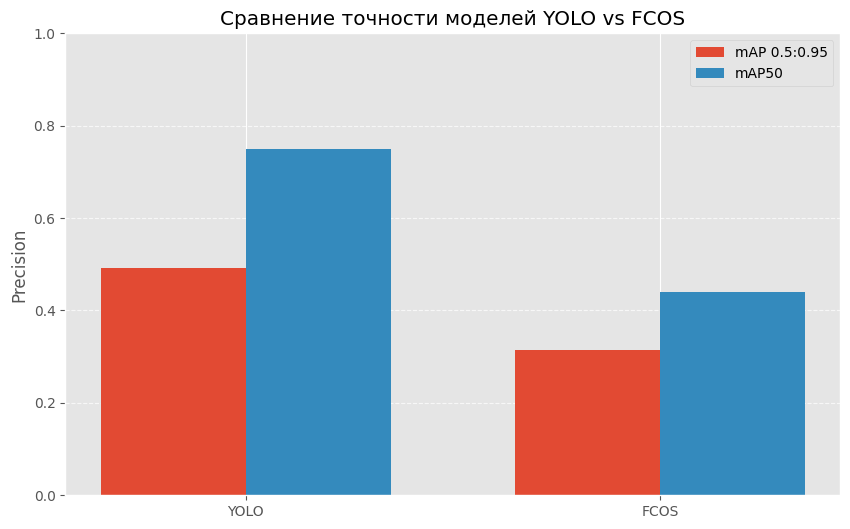

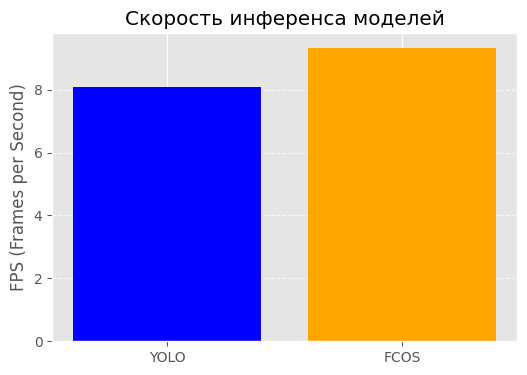

In [41]:
import matplotlib.pyplot as plt
import pandas as pd
import os

# Пути к метрикам
yolo_csv = "artifacts/metrics/yolo_metrics_test.csv"
fcos_csv = "artifacts/metrics/fcos_metrics_test.csv"

# Загружаем метрики FCOS
df_fcos = pd.read_csv(fcos_csv)

# Загружаем метрики YOLO
if os.path.exists(yolo_csv):
    df_yolo = pd.read_csv(yolo_csv)
else:
    raise FileNotFoundError(f"CSV YOLO не найден по пути: {yolo_csv}")

# Формируем объединённый датафрейм
compare_df = pd.DataFrame({
    "Model": ["YOLO", "FCOS"],
    "mAP": [df_yolo['mAP'].values[0], df_fcos['mAP'].values[0]],
    "mAP50": [df_yolo['mAP50'].values[0], df_fcos['mAP50'].values[0]],
    "FPS": [df_yolo['FPS'].values[0] if 'FPS' in df_yolo.columns else None, df_fcos['FPS'].values[0]]
})

print("\n=== Сравнительная таблица YOLO vs FCOS ===")
print(compare_df)

# -----------------------------
# График точности mAP и mAP50
# -----------------------------
plt.figure(figsize=(10,6))
bar_width = 0.35
x = range(len(compare_df))

plt.bar([i - bar_width/2 for i in x], compare_df['mAP'], width=bar_width, label='mAP 0.5:0.95')
plt.bar([i + bar_width/2 for i in x], compare_df['mAP50'], width=bar_width, label='mAP50')

plt.xticks(x, compare_df['Model'])
plt.ylabel('Precision')
plt.ylim(0, 1)
plt.title('Сравнение точности моделей YOLO vs FCOS')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# -----------------------------
# График FPS
# -----------------------------
plt.figure(figsize=(6,4))
fps_values = [f if f is not None else 0 for f in compare_df['FPS']]
plt.bar(compare_df['Model'], fps_values, color=['blue', 'orange'])
plt.ylabel('FPS (Frames per Second)')
plt.title('Скорость инференса моделей')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Вывод:

4 и 5 и 6 этапы для FCOS Закончены. Применены стандартные аугуменации. Метрики на стандартном обучении

Для FCOS: 
Средняя точность по всем объектам — 31.4%, по mAP50 — 44.1%.
Скорость инференса — ~9 кадров в секунду.

Для простой модели обученной на 12 эпохах результат можно считать удовлетворительным. 
mAP для маленьких объектов всего 0.042 — это очень низко, значит маленькие объекты почти не детектируются.
mAP для больших объектов 0.44 — уже неплохо.


Для YOLO:
     mAP     mAP50       FPS
  0.490939  0.748965  8.086550 -- Yolo показало лучшую точность на 12 эпохах. Что неожиданно, так как на виндоус на CPU на 1 эпохе YOLO показывало намного худшую точность при намного большей скорости. На CUDA даже скорость у FCOS выше - при худней точности. 
  В целом точность YOLO на уроне 0,5 mAP и 0,75 mAP50 - говорит о немлохой точности с мягким порогом 0,5. 
  

С учетом вышеизложенно если останется время, можно будет переобучить модель на "малых объектах" и с учетом дисбаланса классов. 

Но следующим шагом будет обучение YOLO - сам файл с обучением модели в mmdetection\train_yolo_minecraft.py